In [4]:
# to know max and min values in the column
import pandas as pd   

# loading the dataset into a variable called df 
# we use train becuase we want to look at the target variable 
df = pd.read_csv('/Users/parulchaudhary/Desktop/SEM 2/Predictive/Predictive Project/Data/train.csv')

# .min() gives us the smallest value in the var15 column
print("Minimum value of var15:", df['var15'].min())

# .max() gives us the largest value in the var15 column
print("Maximum value of var15:", df['var15'].max())


Minimum value of var15: 5
Maximum value of var15: 105


In [6]:
# count of customers where var15 is less than 18
print((df['var15'] < 18).sum())

212


In [7]:
# filtering customers who are below age 18 AND are unhappy (TARGET = 1)
# & means both conditions must be true at the same time
print(((df['var15'] < 18) & (df['TARGET'] == 1)).sum())

0


In [8]:
# finding the minimum age among unhappy customers only
# df[df['TARGET'] == 1] filters only unhappy customers
# then we pick the var15 column and find the minimum value
print(df[df['TARGET'] == 1]['var15'].min())

23


In [9]:
# counting total customers below age 23
print((df['var15'] < 23).sum())

1212


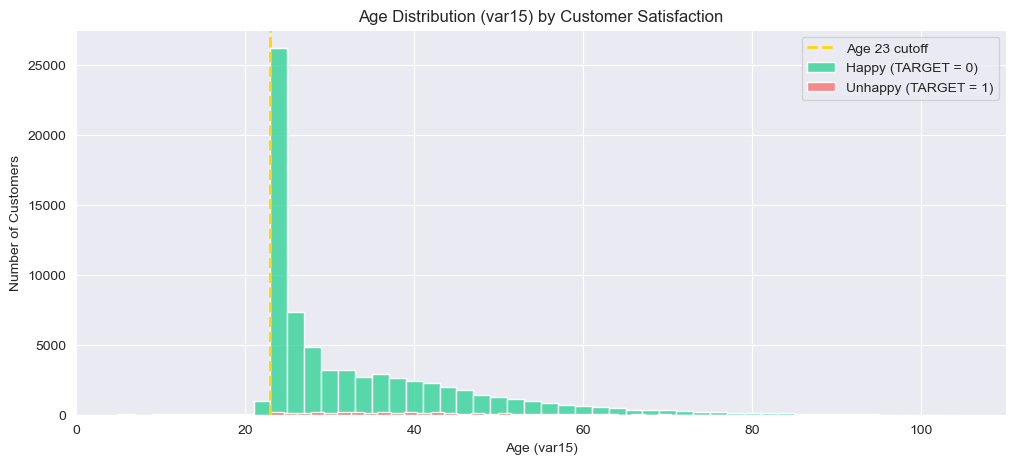

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# set dark background style
sns.set_style("darkgrid")

# separate happy and unhappy ages
happy_ages = df[df['TARGET'] == 0]['var15']
unhappy_ages = df[df['TARGET'] == 1]['var15']

plt.figure(figsize=(12, 5))

# plot both distributions
sns.histplot(happy_ages, bins=50, color='#34d399', alpha=0.8, label='Happy (TARGET = 0)')
sns.histplot(unhappy_ages, bins=50, color='#f87171', alpha=0.8, label='Unhappy (TARGET = 1)')

# age 23 cutoff line
plt.axvline(x=23, color='gold', linewidth=2, linestyle='--', label='Age 23 cutoff')

plt.title('Age Distribution (var15) by Customer Satisfaction')
plt.xlabel('Age (var15)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

In [ ]:
DAY-3

In [1]:
import pandas as pd

# load train and test
train = pd.read_csv('/Users/parulchaudhary/Desktop/SEM 2/Predictive/Predictive Project/Data/train.csv')
test = pd.read_csv('/Users/parulchaudhary/Desktop/SEM 2/Predictive/Predictive Project/Data/test.csv')

# check shapes before concat
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (76020, 371)
Test shape: (75818, 370)


In [2]:
# save target separately before concat
target = train['TARGET']

# drop TARGET and ID from both before concat
train_clean = train.drop(columns=['TARGET', 'ID'])
test_clean = test.drop(columns=['ID'])

# concat train and test together
combined = pd.concat([train_clean, test_clean], axis=0, ignore_index=True)

# check shape
print("Combined shape:", combined.shape)

Combined shape: (151838, 369)


In [3]:
# save the column list before any cleaning
cols_before = combined.columns.tolist()

# print how many columns we have before cleaning
print("Number of features BEFORE cleaning:", len(cols_before))

Number of features BEFORE cleaning: 369


In [4]:
# find columns where number of unique values is exactly 1
constant_cols = [col for col in combined.columns if combined[col].nunique() == 1]

# print how many constant columns we found
print("Number of constant features:", len(constant_cols))
print("Constant features:", constant_cols)

Number of constant features: 34
Constant features: ['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var41', 'ind_var46_0', 'ind_var46', 'num_var27_0', 'num_var28_0', 'num_var28', 'num_var27', 'num_var41', 'num_var46_0', 'num_var46', 'saldo_var28', 'saldo_var27', 'saldo_var41', 'saldo_var46', 'imp_amort_var18_hace3', 'imp_amort_var34_hace3', 'imp_reemb_var13_hace3', 'imp_reemb_var33_hace3', 'imp_trasp_var17_out_hace3', 'imp_trasp_var33_out_hace3', 'num_var2_0_ult1', 'num_var2_ult1', 'num_reemb_var13_hace3', 'num_reemb_var33_hace3', 'num_trasp_var17_out_hace3', 'num_trasp_var33_out_hace3', 'saldo_var2_ult1', 'saldo_medio_var13_medio_hace3']


In [5]:
# drop constant columns from combined
combined = combined.drop(columns=constant_cols)

# check shape after dropping constants
print("Shape after dropping constant features:", combined.shape)
print("Features remaining:", combined.shape[1])

Shape after dropping constant features: (151838, 335)
Features remaining: 335


In [8]:
# transpose the dataframe so columns become rows
# this lets us use duplicated() to find identical columns
duplicate_cols = combined.T[combined.T.duplicated()].index.tolist()

# print how many duplicate columns we found
print("Number of duplicate features:", len(duplicate_cols))
print("Duplicate features:", duplicate_cols)

Number of duplicate features: 27
Duplicate features: ['ind_var13_medio', 'ind_var18', 'ind_var26', 'ind_var25', 'ind_var29_0', 'ind_var29', 'ind_var32', 'ind_var34', 'ind_var37', 'ind_var39', 'num_var18', 'num_var26', 'num_var25', 'num_var29_0', 'num_var29', 'num_var32', 'num_var34', 'num_var37', 'num_var39', 'saldo_var29', 'delta_num_reemb_var13_1y3', 'delta_num_reemb_var17_1y3', 'delta_num_reemb_var33_1y3', 'delta_num_trasp_var17_in_1y3', 'delta_num_trasp_var17_out_1y3', 'delta_num_trasp_var33_in_1y3', 'delta_num_trasp_var33_out_1y3']


In [9]:
# drop duplicate columns from combined
combined = combined.drop(columns=duplicate_cols)

# check shape after dropping duplicates
print("Shape after dropping duplicate features:", combined.shape)
print("Features remaining:", combined.shape[1])

Shape after dropping duplicate features: (151838, 308)
Features remaining: 308


In [10]:
# save column list after cleaning
cols_after = combined.columns.tolist()

# print the full summary
print("===== CLEANING SUMMARY =====")
print("Features BEFORE cleaning:", len(cols_before))
print("Constant features removed:", len(constant_cols))
print("Duplicate features removed:", len(duplicate_cols))
print("Features AFTER cleaning:", len(cols_after))

===== CLEANING SUMMARY =====
Features BEFORE cleaning: 369
Constant features removed: 34
Duplicate features removed: 27
Features AFTER cleaning: 308


In [ ]:
Day-4

In [17]:
# Separate features, target and test features
import numpy as np
X_raw = train.drop(columns=["ID", "TARGET"])
y     = train["TARGET"]
X_test_raw = test.drop(columns=["ID"])

# Verify shapes
print("Train shape:", X_raw.shape)
print("Test shape :", X_test_raw.shape)

Train shape: (76020, 369)
Test shape : (75818, 369)


In [18]:
# ── DAY 3 CLEANING (Parul) ──
# Drop constant columns (columns with only one unique value)
constant_cols = [col for col in X_raw.columns if X_raw[col].nunique() == 1]
X_raw = X_raw.drop(columns=constant_cols)

print(f"Dropped {len(constant_cols)} constant cols → {X_raw.shape[1]} remaining")

# Drop duplicate columns
X_raw = X_raw.T.drop_duplicates().T

print(f"After dropping duplicates → {X_raw.shape[1]} remaining")

Dropped 34 constant cols → 335 remaining
After dropping duplicates → 306 remaining


In [19]:
# Drop sparse columns (more than 99% zeros - not useful)
sparse_cols = [col for col in X_raw.columns if (X_raw[col] == 0).mean() > 0.99]
X_raw = X_raw.drop(columns=sparse_cols)

print(f"Dropped {len(sparse_cols)} sparse cols → {X_raw.shape[1]} remaining")

Dropped 163 sparse cols → 143 remaining


In [20]:
# Drop highly correlated columns (correlation > 0.98 - they carry the same info)
corr_matrix = X_raw.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.98)]
X_raw = X_raw.drop(columns=high_corr_cols)

print(f"Dropped {len(high_corr_cols)} correlated cols → {X_raw.shape[1]} remaining")

Dropped 32 correlated cols → 111 remaining


In [21]:
# Flag elderly customers (age > 80)
X_raw["is_elderly"] = (X_raw["var15"] > 80).astype(int)

print(f"is_elderly: {X_raw['is_elderly'].sum()} customers flagged")

is_elderly: 558 customers flagged


In [22]:
# Check age distribution by TARGET
print(train.groupby("TARGET")["var15"].describe())

          count       mean        std   min   25%   50%   75%    max
TARGET                                                              
0       73012.0  32.946406  12.924444   5.0  23.0  27.0  39.0  105.0
1        3008.0  39.680519  12.020518  23.0  30.0  38.0  47.0  102.0


In [24]:
# Test AUC lift of is_elderly
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y, X_raw["is_elderly"])
print(f"is_elderly AUC: {auc:.4f}")

is_elderly AUC: 0.4986


In [25]:
# Find all saldo (balance) columns in our feature set
saldo_cols = [col for col in X_raw.columns if "saldo" in col]
print(f"Saldo columns: {len(saldo_cols)}")
print(saldo_cols)

Saldo columns: 20
['saldo_var5', 'saldo_var8', 'saldo_var12', 'saldo_var13_corto', 'saldo_var13', 'saldo_var26', 'saldo_var30', 'saldo_var37', 'saldo_var42', 'saldo_medio_var5_hace2', 'saldo_medio_var5_hace3', 'saldo_medio_var5_ult1', 'saldo_medio_var5_ult3', 'saldo_medio_var8_hace2', 'saldo_medio_var8_ult1', 'saldo_medio_var8_ult3', 'saldo_medio_var12_hace2', 'saldo_medio_var12_hace3', 'saldo_medio_var13_corto_hace2', 'saldo_medio_var13_corto_hace3']


In [26]:
# Flag customers where ALL saldo (balance) columns are zero - likely inactive customers
X_raw["saldo_zero"] = (X_raw[saldo_cols] == 0).all(axis=1).astype(int)

print(f"saldo_zero: {X_raw['saldo_zero'].sum()} customers flagged")

saldo_zero: 19244 customers flagged


In [27]:
# Test AUC lift of saldo_zero
auc = roc_auc_score(y, X_raw["saldo_zero"])
print(f"saldo_zero AUC: {auc:.4f}")

saldo_zero AUC: 0.6649


In [28]:
# var38 = likely customer salary/income
# The most common value (117310.979) is a sentinel - it means data is missing
print(f"var38 mode: {train['var38'].mode()[0]}")
print(f"How many customers have this value: {(train['var38'] == train['var38'].mode()[0]).sum()}")

var38 mode: 117310.979016494
How many customers have this value: 14868


In [29]:
# Flag customers where var38 equals the sentinel value (missing income data)
var38_mode = train["var38"].mode()[0]
X_raw["var38_is_mode"] = (train["var38"] == var38_mode).astype(int)

print(f"var38_is_mode: {X_raw['var38_is_mode'].sum()} customers flagged")


var38_is_mode: 14868 customers flagged


In [30]:
# Test AUC lift of var38_is_mode
auc = roc_auc_score(y, X_raw["var38_is_mode"])
print(f"var38_is_mode AUC: {auc:.4f}")

var38_is_mode AUC: 0.5044


In [31]:
# Flag customers where 3-month average balance for product 5 is zero
X_raw["saldo5_ult3_zero"] = (train["saldo_medio_var5_ult3"] == 0).astype(int)

print(f"saldo5_ult3_zero: {X_raw['saldo5_ult3_zero'].sum()} customers flagged")

saldo5_ult3_zero: 24664 customers flagged


In [32]:
# Test AUC lift of saldo5_ult3_zero
auc = roc_auc_score(y, X_raw["saldo5_ult3_zero"])
print(f"saldo5_ult3_zero AUC: {auc:.4f}")

saldo5_ult3_zero AUC: 0.6650


In [33]:
# Save the final dataset with new flags
X_raw["TARGET"] = y.values
X_raw.to_csv("parul_day4_train.csv", index=False)

print(f"Saved! Final shape: {X_raw.shape}")

Saved! Final shape: (76020, 116)
